In [1]:
import pandas as pd
import matplotlib.pyplot as plt
d = pd.read_csv("./data/ili_data.csv")
d_hhs3 = d.loc[ d.region == "hhs3" ].reset_index()


d_hhs3["year"] = d_hhs3["epiweek"] // 100
d_hhs3["week"] = d_hhs3["epiweek"] % 100
d_hhs3["date"] = pd.to_datetime(
    d_hhs3["year"].astype(str)
    + "-W"
    + d_hhs3["week"].astype(str).str.zfill(2)
    + "-1",
    format="%G-W%V-%u"
)
d_hhs3["month"] = d_hhs3["date"].dt.month
d_hhs3["monthly_ili"] = (
    d_hhs3.groupby(["year", "month"])["num_ili"].transform("sum") /
    d_hhs3.groupby(["year", "month"])["num_patients"].transform("sum")
)
d_hhs3_unique = d_hhs3.drop_duplicates(subset="monthly_ili")
print(d_hhs3_unique)

     index release_date region   issue  epiweek  lag  num_ili  num_patients  \
0        3   2017-10-24   hhs3  201740   201501  143     7757        131608   
1       14   2017-10-24   hhs3  201740   201502  142     6176        130616   
5       58   2017-10-24   hhs3  201740   201506  138     4246        151586   
9      102   2017-10-24   hhs3  201740   201510  134     2284        144346   
14     157   2017-10-24   hhs3  201740   201515  129     2122        145937   
..     ...          ...    ...     ...      ...  ...      ...           ...   
548   6031   2026-01-23   hhs3  202602   202528   27     2119        246867   
552   6075   2026-01-23   hhs3  202602   202532   23     2318        243589   
556   6119   2026-01-23   hhs3  202602   202536   19     3988        255021   
561   6174   2026-01-23   hhs3  202602   202541   14     3928        274445   
565   6218   2026-01-23   hhs3  202602   202545   10     4954        274048   

     num_providers  num_age_0  ...  num_age_3  num_

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from epiweeks import Week

d = pd.read_csv("./data/PA_ILI.csv")
d['date'] = d.apply(
    lambda row: Week(row['YEAR'], row['WEEK']).startdate(),
    axis=1
)

d['date'] = pd.to_datetime(d['date'])

d_monthly = (
    d
    .set_index('date')
    .resample('ME')   
    .sum('%UNWEIGHTED ILI')          
    .reset_index()
)
d_monthly = d_monthly[d_monthly['date'].dt.year >= 2015]

               Vaccine     Geography  FIPS     Year  Month   Dimension  \
58  Seasonal Influenza  Pennsylvania    42  2015-16      2  >=6 Months   
59  Seasonal Influenza  Pennsylvania    42  2015-16      3  >=6 Months   
60  Seasonal Influenza  Pennsylvania    42  2015-16      4  >=6 Months   
61  Seasonal Influenza  Pennsylvania    42  2015-16      5  >=6 Months   
62  Seasonal Influenza  Pennsylvania    42  2015-16      7  >=6 Months   

    Estimate(%)  New_per_Month  YearNumeric  year  month       Date  
58         46.9            1.4         2015  2015      2 2015-02-01  
59         47.5            0.6         2015  2015      3 2015-03-01  
60         48.0            0.5         2015  2015      4 2015-04-01  
61         48.2            0.2         2015  2015      5 2015-05-01  
62          0.4            0.4         2015  2015      7 2015-07-01  
   index release_date region   issue  epiweek  lag  num_ili  num_patients  \
0      3   2017-10-24   hhs3  201740   201501  143     775

/var/folders/zf/ls9dx7c91d76ltvcjs7729d80000gn/T/ipykernel_20331/874405850.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vax_2015_2025.rename(columns={'Season/Survey Year': 'Year'}, inplace=True)
/var/folders/zf/ls9dx7c91d76ltvcjs7729d80000gn/T/ipykernel_20331/874405850.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vax_2015_2025['YearNumeric'] = vax_2015_2025['Year'].str.split('-').str[0].astype(int)
/var/folders/zf/ls9dx7c91d76ltvcjs7729d80000gn/T/ipykernel_20331/874405850.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

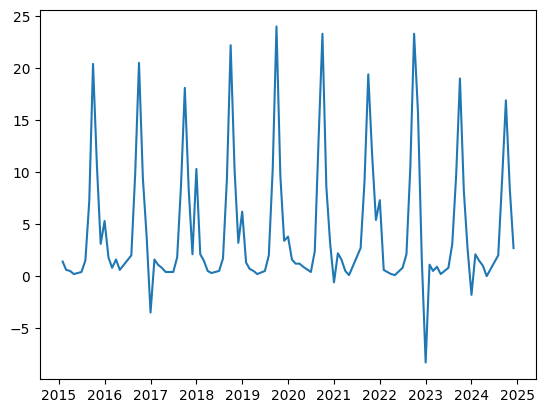

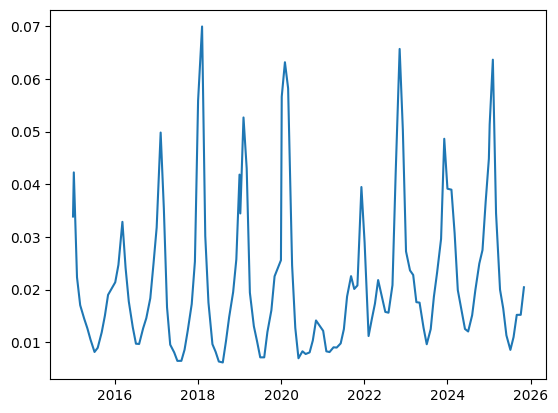

In [2]:

vax = pd.read_csv("./data/Influenza_Vaccination_Coverage_PA.csv")
vax_2015_2025 = vax.loc[58: ] #selects only surveys after 2017
vax_2015_2025.rename(columns={'Season/Survey Year': 'Year'}, inplace=True) 
vax_2015_2025['YearNumeric'] = vax_2015_2025['Year'].str.split('-').str[0].astype(int)
vax_2015_2025['year'] = vax_2015_2025['YearNumeric']
vax_2015_2025['month'] = vax_2015_2025['Month']

vax_2015_2025['Date'] = pd.to_datetime(vax_2015_2025[['year', 'month']].assign(day=1))
print(vax_2015_2025.head())
print(d_hhs3.head())
fig, ax = plt.subplots() 
plt.plot (vax_2015_2025["Date"],vax_2015_2025["New_per_Month"])

fig, ax = plt.subplots()
plt.plot (d_hhs3_unique['date'], d_hhs3_unique['monthly_ili'])

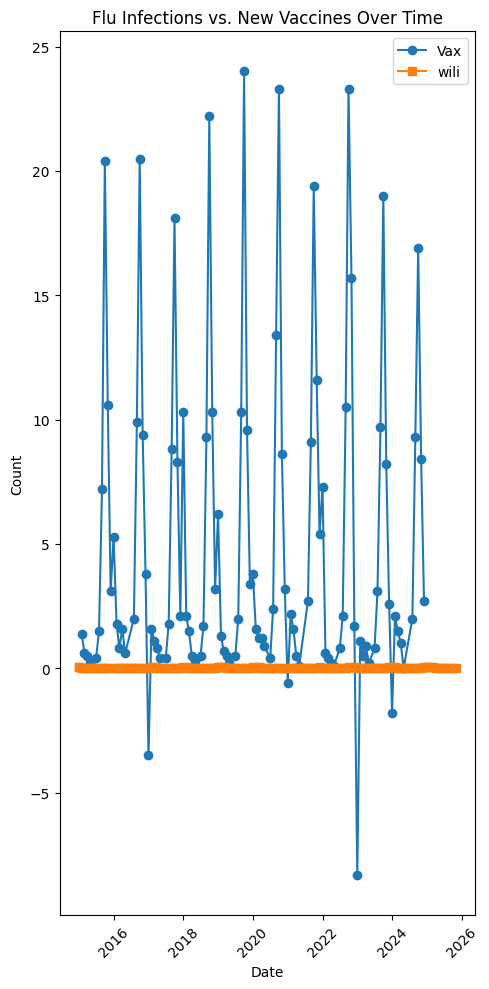

In [3]:
plt.figure(figsize=(5,10))

# Plot Vax
plt.plot(vax_2015_2025['Date'], vax_2015_2025["New_per_Month"], label='Vax', marker='o')

# Plot wili
plt.plot(d_hhs3_unique["date"],d_hhs3_unique["monthly_ili"], label='wili', marker='s')
 
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Flu Infections vs. New Vaccines Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()